# Week 5
## Cross-Notebook Data Import and Neuron Sensitivity Under a Fixed Compression Ratio

This notebook imports intermediate results produced in earlier notebooks and studies how a single compression ratio affects different neurons.

Accuracy here follows the binned spike-count definition introduced in Week 4:

`matched_count = max(n_ref - abs(n_test - n_ref), 0)`

For example, if one neuron fires 50 spikes in the baseline result and 55 spikes after compression in the same bin, the bin contributes `45 / 50`.


In [1]:
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from kilosort import template_matching as ks_tm
from predictor.accuracy_predictor import (
    AccuracyPredictorModel,
    DEFAULT_FEATURE_COLUMNS,
    build_ratio_feature_frame,
    extract_baseline_neuron_features,
    leave_one_ratio_out_cv,
)

ROOT = Path('F:/academic')
DATA_ROOT = ROOT / '.test_data'
BASE_RESULTS = DATA_ROOT / 'kilosort4'

baseline_cache = ROOT / 'baseline_results.npy'
compression_cache = ROOT / 'compression_eval_results.npy'
week4_strict_cache = ROOT / 'week4_kilosort_function_fixed_template_results.npy'
week4_ratio_table = ROOT / 'week4_fixed_template_ratio_compare.csv'

for p in [baseline_cache, compression_cache, week4_strict_cache]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required prior result: {p}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('ROOT:', ROOT)


device: cuda
ROOT: F:\academic


## 1. Cross-Notebook Data Import

This section reuses outputs from earlier notebooks instead of recomputing them:

- `baseline_results.npy` and raw Kilosort baseline outputs from earlier workflow
- `compression_eval_results.npy` from previous compression experiments
- `week4_kilosort_function_fixed_template_results.npy` and `week4_ratio_*.npy` caches from Week 4
- `week4_fixed_template_ratio_compare.csv` if available


In [2]:
# RERUN NOTE: Rerun after 2.ipynb / 4.ipynb refresh their outputs. This cell loads compression_eval_results.npy and week4-derived summaries that become stale after the CAR change.
baseline_res = np.load(baseline_cache, allow_pickle=True).item()
compression_eval = np.load(compression_cache, allow_pickle=True).item()
week4_strict = np.load(week4_strict_cache, allow_pickle=True).item()

ops_base = np.load(BASE_RESULTS / 'ops.npy', allow_pickle=True).item()
templates_base = np.load(BASE_RESULTS / 'templates.npy')
st_base = np.load(BASE_RESULTS / 'spike_times.npy').squeeze().astype(np.int64)
clu_base = np.load(BASE_RESULTS / 'spike_clusters.npy').squeeze().astype(np.int64)

week4_ratio_df = pd.read_csv(week4_ratio_table) if week4_ratio_table.exists() else None

print('baseline spikes:', st_base.shape[0])
print('baseline neurons:', np.unique(clu_base).shape[0])
print('compression_eval ratios:', sorted(float(k) for k in compression_eval.keys()))
print('week4 strict spikes:', np.asarray(week4_strict['st']).shape[0])
if week4_ratio_df is not None:
    display(week4_ratio_df)


baseline spikes: 137381
baseline neurons: 267
compression_eval ratios: [0.1, 0.2]
week4 strict spikes: 123348


,ratio,n_baseline_events,n_detected_events,detection_rate_on_baseline_events,classification_accuracy_on_detected_events,binned_count_accuracy_micro,binned_count_accuracy_macro,matched_spikes_after_binning,baseline_spikes_for_binning,bin_size_seconds
0,0.1,137378,15848,0.115361,0.238264,0.576586,0.545620,79212,137381,1.0
1,0.2,137378,15570,0.113337,0.235710,0.741864,0.660007,101918,137381,1.0
2,0.3,137378,15583,0.113432,0.233331,0.752025,0.669700,103314,137381,1.0
3,0.5,137378,15896,0.115710,0.233140,0.750067,0.667577,103045,137381,1.0
4,0.7,137378,15938,0.116016,0.233906,0.749914,0.667447,103024,137381,1.0


In [3]:
def load_ratio_eval_cache(keep_ratio):
    path = ROOT / f'week4_ratio_{keep_ratio:.2f}_binned_eval.npy'
    if not path.exists() or path.stat().st_size == 0:
        return None
    try:
        obj = np.load(path, allow_pickle=True).item()
        return obj if isinstance(obj, dict) else None
    except Exception:
        return None

available_week4_caches = {}
for ratio in [0.10, 0.20, 0.30, 0.50, 0.70]:
    obj = load_ratio_eval_cache(ratio)
    if obj is not None:
        available_week4_caches[ratio] = obj

cache_overview = pd.DataFrame([
    {
        'ratio': f'{r:.2f}',
        'compressed_bin': str(v.get('compressed_bin', '')),
        'binned_count_accuracy_micro': v.get('binned_count_accuracy_micro', np.nan),
        'matched_spikes_after_binning': v.get('matched_spikes_after_binning', np.nan)
    }
    for r, v in sorted(available_week4_caches.items())
])
display(cache_overview)


,ratio,compressed_bin,binned_count_accuracy_micro,matched_spikes_after_binning
0,0.10,F:\academic\whitened_recon_ratio_0.10.bin,0.576586,79212
1,0.20,F:\academic\whitened_recon_ratio_0.20.bin,0.741864,101918
2,0.30,F:\academic\whitened_recon_ratio_0.30.bin,0.752025,103314
3,0.50,F:\academic\whitened_recon_ratio_0.50.bin,0.750067,103045
4,0.70,F:\academic\whitened_recon_ratio_0.70.bin,0.749914,103024


## 2. Fixed Compression Ratio and Neuron Sensitivity

We choose one compression ratio and ask: under the same compression level, which neurons are more sensitive?

Sensitivity is evaluated per neuron using the same binned count-accuracy rule as in Week 4. A neuron with lower binned accuracy is considered more sensitive to compression.


In [4]:
# Choose a single ratio for neuron-level sensitivity analysis.
# If week4 summary exists, prefer the median tested ratio 0.30; otherwise keep a ratio that already has a recon bin.
analysis_ratio = 0.30
candidate_bin = ROOT / f'whitened_recon_ratio_{analysis_ratio:.2f}.bin'
if not candidate_bin.exists():
    for r in [0.20, 0.10, 0.50, 0.70]:
        p = ROOT / f'whitened_recon_ratio_{r:.2f}.bin'
        if p.exists():
            analysis_ratio = r
            candidate_bin = p
            break
print('analysis_ratio:', analysis_ratio)
print('compressed bin:', candidate_bin)


analysis_ratio: 0.3
compressed bin: F:\academic\whitened_recon_ratio_0.30.bin


In [5]:
def infer_src_n_chan_from_bin(bin_path, dtype=np.float32, candidates=(383, 385)):
    size = Path(bin_path).stat().st_size
    item = np.dtype(dtype).itemsize
    ok = []
    for ch in candidates:
        if size % (ch * item) == 0:
            ok.append(ch)
    if not ok:
        raise ValueError(f'Cannot infer channel count for {bin_path} from size={size}.')
    return 383 if 383 in ok else ok[0]

def sort_full_timeline_with_fixed_templates(bin_path, U, ctc, ops_tm, n_use, nt, device, win=12000):
    data_dtype = np.float32
    src_n_chan = infer_src_n_chan_from_bin(bin_path, dtype=data_dtype, candidates=(383, 385))
    raw = np.memmap(bin_path, dtype=data_dtype, mode='r')
    n_samples_local = raw.size // src_n_chan
    data_cmp_local = raw[: n_samples_local * src_n_chan].reshape(n_samples_local, src_n_chan)

    n_use_local = min(n_use, src_n_chan)
    overlap = nt * 2
    all_t = []
    all_k = []

    for t0 in range(0, n_samples_local, win):
        t1 = min(n_samples_local, t0 + win)
        x0 = max(0, t0 - overlap)
        x1 = min(n_samples_local, t1 + overlap)
        if (x1 - x0) < nt:
            continue

        X_np = np.array(data_cmp_local[x0:x1, :n_use_local].T, dtype=np.float32, copy=True)
        X = torch.from_numpy(X_np).to(device=device, non_blocking=True).contiguous()
        with torch.no_grad():
            stt, _, _, _ = ks_tm.run_matching(ops_tm, X, U[:, :, :n_use_local], ctc, device=device)

        t_abs = stt[:, 0].detach().cpu().numpy().astype(np.int64) + x0
        k_abs = stt[:, 1].detach().cpu().numpy().astype(np.int64)
        keep = (t_abs >= t0) & (t_abs < t1)
        if np.any(keep):
            all_t.append(t_abs[keep])
            all_k.append(k_abs[keep])

        del X
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    if len(all_t) == 0:
        return np.empty((0,), dtype=np.int64), np.empty((0,), dtype=np.int64)

    st_cmp = np.concatenate(all_t)
    clu_cmp = np.concatenate(all_k)
    order = np.argsort(st_cmp)
    return st_cmp[order], clu_cmp[order]

def per_neuron_binned_accuracy(st_ref, clu_ref, st_test, clu_test, bin_size_samples, n_units=None):
    st_ref = np.asarray(st_ref, dtype=np.int64)
    clu_ref = np.asarray(clu_ref, dtype=np.int64)
    st_test = np.asarray(st_test, dtype=np.int64)
    clu_test = np.asarray(clu_test, dtype=np.int64)

    if n_units is None:
        max_ref = int(clu_ref.max()) if clu_ref.size else -1
        max_test = int(clu_test.max()) if clu_test.size else -1
        n_units = max(max_ref, max_test) + 1

    max_time = 0
    if st_ref.size:
        max_time = max(max_time, int(st_ref.max()))
    if st_test.size:
        max_time = max(max_time, int(st_test.max()))
    n_bins = max(1, max_time // int(bin_size_samples) + 1)

    ref_bins = st_ref // int(bin_size_samples) if st_ref.size else np.empty((0,), dtype=np.int64)
    test_bins = st_test // int(bin_size_samples) if st_test.size else np.empty((0,), dtype=np.int64)
    ref_lin = clu_ref * n_bins + ref_bins if st_ref.size else np.empty((0,), dtype=np.int64)
    test_lin = clu_test * n_bins + test_bins if st_test.size else np.empty((0,), dtype=np.int64)

    ref_counts = np.bincount(ref_lin, minlength=n_units * n_bins).reshape(n_units, n_bins)
    test_counts = np.bincount(test_lin, minlength=n_units * n_bins).reshape(n_units, n_bins)
    matched_counts = np.maximum(ref_counts - np.abs(test_counts - ref_counts), 0)

    ref_totals = ref_counts.sum(axis=1)
    test_totals = test_counts.sum(axis=1)
    matched_totals = matched_counts.sum(axis=1)
    acc = np.full(n_units, np.nan, dtype=np.float64)
    valid = ref_totals > 0
    acc[valid] = matched_totals[valid] / ref_totals[valid]

    return pd.DataFrame({
        'neuron_id': np.arange(n_units, dtype=np.int64),
        'baseline_spikes': ref_totals.astype(np.int64),
        'compressed_spikes': test_totals.astype(np.int64),
        'matched_spikes_after_binning': matched_totals.astype(np.int64),
        'binned_count_accuracy': acc,
        'sensitivity': 1.0 - acc
    })


In [6]:
# Prepare fixed-template matching objects exactly as in Week 4.
for _name in ['U', 'ctc', 'wPCA_t', 'tpl_t', 'X']:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass
gc.collect()
if device.type == 'cuda':
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass

n_templates, nt, n_chan_tpl = templates_base.shape
src_n_chan = infer_src_n_chan_from_bin(candidate_bin, dtype=np.float32, candidates=(383, 385))
n_use = min(n_chan_tpl, src_n_chan)
templates_fixed = templates_base[:, :, :n_use].astype(np.float32, copy=False)

ops_tm = dict(ops_base)
ops_tm['settings'] = dict(ops_base.get('settings', {}))
ops_tm['nt'] = int(nt)
ops_tm['nt0min'] = int(ops_base.get('nt0min', nt // 2))
ops_tm['Th_learned'] = float(ops_base.get('Th_learned', 8))
ops_tm['max_peels'] = int(ops_base.get('max_peels', 8))

wPCA = ops_base.get('wPCA', None)
if wPCA is None:
    raise RuntimeError('ops_base does not contain wPCA required by template_matching.run_matching')
wPCA_t = torch.from_numpy(np.asarray(wPCA, dtype=np.float32)).to(device=device).contiguous()
ops_tm['wPCA'] = wPCA_t

tpl_t = torch.as_tensor(templates_fixed, dtype=torch.float32, device=device)
U = torch.einsum('utc,pt->upc', tpl_t, wPCA_t).contiguous()
del tpl_t
ctc = ks_tm.prepare_matching(ops_tm, U)

print('templates:', templates_fixed.shape)
print('channels used:', n_use)
print('wPCA:', tuple(wPCA_t.shape), 'U:', tuple(U.shape), 'ctc:', tuple(ctc.shape))


templates: (267, 61, 383)
channels used: 383
wPCA: (6, 61) U: (267, 6, 383) ctc: (267, 267, 123)


In [7]:
# RERUN NOTE: Must rerun after reconstructed bins are refreshed. This cell reads or rebuilds week5_neuron_sensitivity_ratio_*.npy from the current ratio bin.
analysis_cache = ROOT / f'week5_neuron_sensitivity_ratio_{analysis_ratio:.2f}.npy'
use_cache = False

if analysis_cache.exists() and analysis_cache.stat().st_size > 0:
    try:
        cached = np.load(analysis_cache, allow_pickle=True).item()
        required = {'ratio', 'compressed_bin', 'bin_size_samples', 'sample_rate', 'per_neuron_table'}
        if set(required).issubset(cached.keys()):
            if Path(cached['compressed_bin']) == candidate_bin:
                if float(cached['sample_rate']) == float(ops_base['fs']):
                    use_cache = True
                    neuron_df = pd.DataFrame(cached['per_neuron_table'])
                    print('loaded cached neuron sensitivity analysis:', analysis_cache)
    except Exception as e:
        print('week5 cache invalid, recomputing:', e)

if not use_cache:
    st_cmp_ratio, clu_cmp_ratio = sort_full_timeline_with_fixed_templates(candidate_bin, U, ctc, ops_tm, n_use, nt, device)
    bin_size_samples = int(round(float(ops_base['fs'])))
    neuron_df = per_neuron_binned_accuracy(st_base, clu_base, st_cmp_ratio, clu_cmp_ratio, bin_size_samples, n_units=U.shape[0])
    neuron_df['ratio'] = f'{analysis_ratio:.2f}'
    payload = {
        'ratio': float(analysis_ratio),
        'compressed_bin': str(candidate_bin),
        'bin_size_samples': int(bin_size_samples),
        'sample_rate': float(ops_base['fs']),
        'per_neuron_table': neuron_df.to_dict(orient='records')
    }
    np.save(analysis_cache, payload, allow_pickle=True)
    print('saved:', analysis_cache)


loaded cached neuron sensitivity analysis: F:\academic\week5_neuron_sensitivity_ratio_0.30.npy


In [13]:
neuron_df = neuron_df[neuron_df['baseline_spikes'] > 0].copy()
neuron_df = neuron_df.sort_values(['binned_count_accuracy', 'baseline_spikes'], ascending=[True, False]).reset_index(drop=True)
display(neuron_df.head(20))

print('mean binned neuron accuracy:', float(neuron_df['binned_count_accuracy'].mean()))
print('median binned neuron accuracy:', float(neuron_df['binned_count_accuracy'].median()))
print('most sensitive neuron id:', int(neuron_df.iloc[0]['neuron_id']))
print('least sensitive neuron id:', int(neuron_df.iloc[-1]['neuron_id']))


,neuron_id,baseline_spikes,compressed_spikes,matched_spikes_after_binning,binned_count_accuracy,sensitivity,ratio
0,246,106,548,0,0.000000,1.000000,0.30
1,250,73,585,0,0.000000,1.000000,0.30
2,203,58,255,0,0.000000,1.000000,0.30
3,125,21,188,1,0.047619,0.952381,0.30
4,199,43,162,3,0.069767,0.930233,0.30
5,166,124,322,21,0.169355,0.830645,0.30
6,106,270,518,49,0.181481,0.818519,0.30
7,172,190,442,35,0.184211,0.815789,0.30
8,110,94,249,18,0.191489,0.808511,0.30
9,159,88,253,17,0.193182,0.806818,0.30


mean binned neuron accuracy: 0.6697004431379966
median binned neuron accuracy: 0.7112211221122112
most sensitive neuron id: 246
least sensitive neuron id: 6


### Interpretation

- Lower `binned_count_accuracy` means stronger sensitivity to compression.
- Higher `sensitivity = 1 - accuracy` means the neuron's spike-count profile changes more under the same compression ratio.
- This is a neuron-level count stability measure, not an event-by-event timing score.


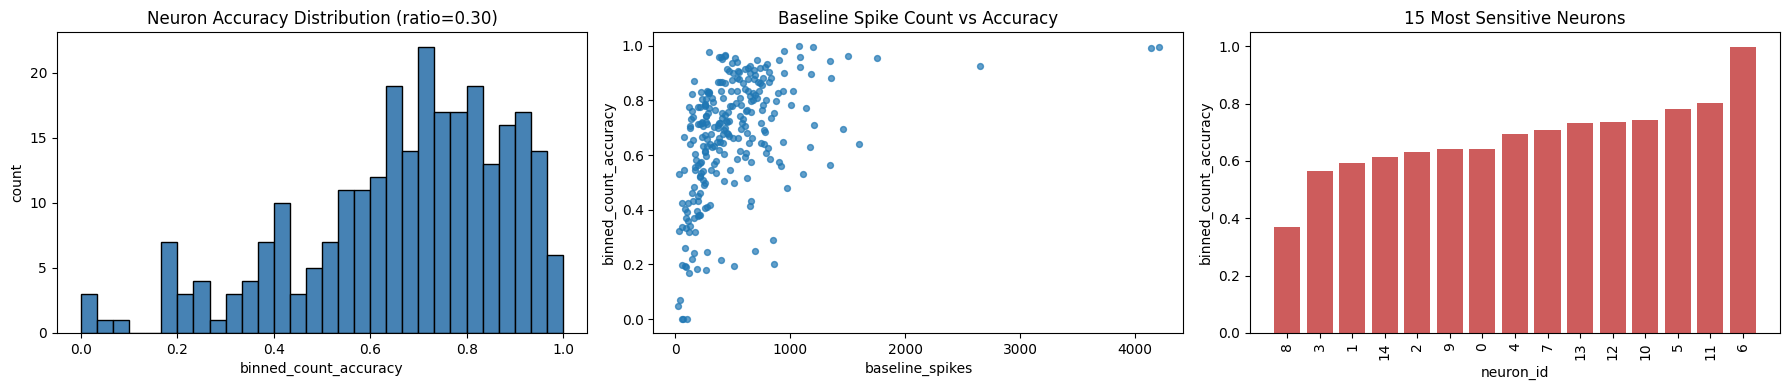

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(neuron_df['binned_count_accuracy'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title(f'Neuron Accuracy Distribution (ratio={analysis_ratio:.2f})')
axes[0].set_xlabel('binned_count_accuracy')
axes[0].set_ylabel('count')

axes[1].scatter(neuron_df['baseline_spikes'], neuron_df['binned_count_accuracy'], s=18, alpha=0.7)
axes[1].set_title('Baseline Spike Count vs Accuracy')
axes[1].set_xlabel('baseline_spikes')
axes[1].set_ylabel('binned_count_accuracy')

top_sensitive = neuron_df.head(15).sort_values('binned_count_accuracy', ascending=True)
axes[2].bar(top_sensitive['neuron_id'].astype(str), top_sensitive['binned_count_accuracy'], color='indianred')
axes[2].set_title('15 Most Sensitive Neurons')
axes[2].set_xlabel('neuron_id')
axes[2].set_ylabel('binned_count_accuracy')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


In [9]:
export_path = ROOT / f'week5_neuron_sensitivity_ratio_{analysis_ratio:.2f}.csv'
neuron_df.to_csv(export_path, index=False)
print('saved:', export_path)


saved: F:\academic\week5_neuron_sensitivity_ratio_0.30.csv


## 3. Accuracy Predictor for Probe Data and Compression Ratio

This section builds a reusable predictor that estimates `binned_count_accuracy` from probe-level neuron features and a chosen compression ratio.

Selected features used by the model:

- `compression_ratio`: the input compression ratio
- `baseline_spikes`: baseline spike count of the neuron
- `firing_rate_hz`: baseline firing rate over the recording
- `template_ptp_mean`: mean peak-to-peak amplitude across channels
- `template_ptp_max`: max peak-to-peak amplitude across channels
- `template_energy`: mean squared template energy
- `dominant_channel`: channel index with the largest template peak-to-peak amplitude
- `template_width_samples`: distance between template trough and peak on the dominant channel

The target is per-neuron `binned_count_accuracy`. Probe-level predicted accuracy is the mean of predicted neuron accuracies for that probe.


In [10]:
predictor_cache = ROOT / 'predictor' / 'week5_accuracy_predictor_training_data.csv'
predictor_model_path = ROOT / 'predictor' / 'week5_accuracy_predictor_model.npy'
predictor_feature_df = extract_baseline_neuron_features(templates_base, st_base, clu_base, sample_rate=float(ops_base['fs']))
predictor_feature_df.head()


,neuron_id,baseline_spikes,firing_rate_hz,template_ptp_mean,template_ptp_max,template_energy,dominant_channel,template_width_samples
0,0,748,16.622321,0.030026,4.468421,0.004847,3,23
1,1,605,13.444524,0.034374,3.342264,0.004241,3,13
2,2,1175,26.111266,0.036586,4.025699,0.004520,2,15
3,3,1351,30.022400,0.022977,4.626841,0.004303,1,20
4,4,1464,32.533526,0.023190,4.502786,0.004064,1,17


In [11]:
# RERUN NOTE: Must rerun after reconstructed bins and week5_neuron_sensitivity_ratio_*.npy are refreshed. This cell assembles the predictor training set from those caches.
training_ratios = [0.10, 0.20, 0.30, 0.50, 0.70]
predictor_records = []
bin_size_samples = int(round(float(ops_base['fs'])))

for ratio in training_ratios:
    ratio_cache = ROOT / f'week5_neuron_sensitivity_ratio_{ratio:.2f}.npy'
    ratio_bin = ROOT / f'whitened_recon_ratio_{ratio:.2f}.bin'

    ratio_neuron_df = None
    if ratio_cache.exists() and ratio_cache.stat().st_size > 0:
        try:
            cached = np.load(ratio_cache, allow_pickle=True).item()
            ratio_neuron_df = pd.DataFrame(cached['per_neuron_table'])
            print(f'loaded cached neuron table for ratio={ratio:.2f}:', ratio_cache.name)
        except Exception as e:
            print(f'cache read failed for ratio={ratio:.2f}, recomputing:', e)

    if ratio_neuron_df is None:
        if not ratio_bin.exists():
            print(f'skip ratio={ratio:.2f}: missing bin {ratio_bin.name}')
            continue
        st_cmp_ratio, clu_cmp_ratio = sort_full_timeline_with_fixed_templates(ratio_bin, U, ctc, ops_tm, n_use, nt, device)
        ratio_neuron_df = per_neuron_binned_accuracy(st_base, clu_base, st_cmp_ratio, clu_cmp_ratio, bin_size_samples, n_units=U.shape[0])
        ratio_neuron_df['ratio'] = f'{ratio:.2f}'
        payload = {
            'ratio': float(ratio),
            'compressed_bin': str(ratio_bin),
            'bin_size_samples': int(bin_size_samples),
            'sample_rate': float(ops_base['fs']),
            'per_neuron_table': ratio_neuron_df.to_dict(orient='records')
        }
        np.save(ratio_cache, payload, allow_pickle=True)
        print(f'saved neuron table for ratio={ratio:.2f}:', ratio_cache.name)

    predictor_records.append(build_ratio_feature_frame(predictor_feature_df, ratio, ratio_neuron_df))

predictor_train_df = pd.concat(predictor_records, ignore_index=True)
predictor_train_df = predictor_train_df[predictor_train_df['baseline_spikes'] > 0].copy()
predictor_train_df.to_csv(predictor_cache, index=False)
print('saved training data:', predictor_cache)
print('training rows:', len(predictor_train_df))
display(predictor_train_df.head())


loaded cached neuron table for ratio=0.10: week5_neuron_sensitivity_ratio_0.10.npy
loaded cached neuron table for ratio=0.20: week5_neuron_sensitivity_ratio_0.20.npy
loaded cached neuron table for ratio=0.30: week5_neuron_sensitivity_ratio_0.30.npy
loaded cached neuron table for ratio=0.50: week5_neuron_sensitivity_ratio_0.50.npy
loaded cached neuron table for ratio=0.70: week5_neuron_sensitivity_ratio_0.70.npy
saved training data: F:\academic\predictor\week5_accuracy_predictor_training_data.csv
training rows: 1335


,neuron_id,baseline_spikes,firing_rate_hz,template_ptp_mean,template_ptp_max,template_energy,dominant_channel,template_width_samples,compression_ratio,binned_count_accuracy,sensitivity,compressed_spikes
0,0,748,16.622321,0.030026,4.468421,0.004847,3,23,0.1,0.882353,0.117647,810
1,1,605,13.444524,0.034374,3.342264,0.004241,3,13,0.1,0.783471,0.216529,506
2,2,1175,26.111266,0.036586,4.025699,0.004520,2,15,0.1,0.680851,0.319149,800
3,3,1351,30.022400,0.022977,4.626841,0.004303,1,20,0.1,0.566247,0.433753,995
4,4,1464,32.533526,0.023190,4.502786,0.004064,1,17,0.1,0.637295,0.362705,939


In [12]:
# RERUN NOTE: Rerun after the predictor training-set cell above. This retrains and overwrites the saved predictor model using post-CAR targets.
feature_columns = list(DEFAULT_FEATURE_COLUMNS)
target_column = 'binned_count_accuracy'

predictor_model = AccuracyPredictorModel.train(
    predictor_train_df,
    feature_columns=feature_columns,
    target_column=target_column,
    alpha=1.0,
)
predictor_model.save(predictor_model_path)

train_pred_df = predictor_model.predict_dataframe(predictor_train_df)
cv_df, cv_summary = leave_one_ratio_out_cv(
    predictor_train_df,
    feature_columns=feature_columns,
    target_column=target_column,
    alpha=1.0,
)

coef_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': predictor_model.coefficients_
}).sort_values('coefficient', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print('saved model:', predictor_model_path)
print('training metrics:', predictor_model.training_metrics_)
print('leave-one-ratio-out summary:', cv_summary)
display(cv_df)
display(coef_df)


saved model: F:\academic\predictor\week5_accuracy_predictor_model.npy
training metrics: {'mae': 0.1764507080289572, 'rmse': 0.2217331141186278, 'r2': 0.1661836857553094}
leave-one-ratio-out summary: {'mae': 0.1816536221835529, 'rmse': 0.23314002276151347, 'r2': 0.0781867542552176}


,held_out_ratio,mae,rmse,r2
0,0.1,0.230161,0.307456,-0.063193
1,0.2,0.174770,0.208825,0.158117
2,0.3,0.169515,0.207364,0.087519
3,0.5,0.166240,0.206635,0.104280
4,0.7,0.167582,0.218944,-0.006257


,feature,coefficient
0,template_ptp_max,-0.039732
1,firing_rate_hz,0.032533
2,baseline_spikes,0.032533
3,compression_ratio,0.030383
4,dominant_channel,-0.028782
5,template_ptp_mean,-0.012690
6,template_energy,0.008498
7,template_width_samples,0.007090


In [13]:
example_ratio = 0.30
probe_prediction = predictor_model.predict_probe_accuracy_from_files(
    templates_path=BASE_RESULTS / 'templates.npy',
    spike_times_path=BASE_RESULTS / 'spike_times.npy',
    spike_clusters_path=BASE_RESULTS / 'spike_clusters.npy',
    ops_path=BASE_RESULTS / 'ops.npy',
    ratio=example_ratio,
)
print('example ratio:', example_ratio)
print('predicted probe mean accuracy:', probe_prediction['predicted_probe_accuracy_mean'])
display(
    probe_prediction['predicted_neuron_accuracy_table'][['neuron_id', 'compression_ratio', 'predicted_accuracy']].head(10)
)


example ratio: 0.3
predicted probe mean accuracy: 0.6323213270962109


,neuron_id,compression_ratio,predicted_accuracy
0,0,0.3,0.747122
1,1,0.3,0.719640
2,2,0.3,0.796779
3,3,0.3,0.828371
4,4,0.3,0.840733
5,5,0.3,0.610813
6,6,0.3,0.738113
7,7,0.3,0.726376
8,8,0.3,0.619522
9,9,0.3,0.756370


### How to Call the Predictor from Python

The reusable implementation is stored in `predictor/accuracy_predictor.py`.

Shortest file-based call:

```python
from pathlib import Path
from predictor.accuracy_predictor import AccuracyPredictorModel

ROOT = Path('F:/academic')
BASE_RESULTS = ROOT / '.test_data/kilosort4'

model = AccuracyPredictorModel.load(ROOT / 'predictor/week5_accuracy_predictor_model.npy')
result = model.predict_probe_accuracy_from_files(
    templates_path=BASE_RESULTS / 'templates.npy',
    spike_times_path=BASE_RESULTS / 'spike_times.npy',
    spike_clusters_path=BASE_RESULTS / 'spike_clusters.npy',
    ops_path=BASE_RESULTS / 'ops.npy',
    ratio=0.30,
)

print(result['predicted_probe_accuracy_mean'])
print(result['predicted_neuron_accuracy_table'].head())
```

If you already have arrays in memory, you can still use `extract_baseline_neuron_features(...)` plus `predict_probe_accuracy(...)`.
